# Wine Dataset Visualization Project

**Student:** Shalaunda Bennett  
**Project Type:** Data Visualization  

This project explores the built-in Wine dataset from scikit-learn. The goal is to use Python, Pandas, and Matplotlib to identify patterns, compare wine classes, and communicate findings through clear visualizations.

## Project Objectives

- Load a real-world classification dataset.
- Inspect and prepare the data for visualization.
- Compare the three wine classes.
- Explore feature distributions and relationships.
- Identify variables that help distinguish wine classes.
- Summarize practical findings from the visual analysis.

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 1. Load and Prepare the Dataset

In [6]:
# Load the Wine dataset as a Pandas DataFrame
wine = load_wine(as_frame=True)
df = wine.frame.copy()

# Replace numeric target values with descriptive class labels
class_names = {index: name for index, name in enumerate(wine.target_names)}
df["wine_class"] = df["target"].map(class_names)
df = df.drop(columns="target")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 178
Columns: 14


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [8]:
# Review data types and missing values
summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique()
})
summary

,data_type,missing_values,unique_values
alcohol,float64,0,126
malic_acid,float64,0,133
ash,float64,0,79
alcalinity_of_ash,float64,0,63
magnesium,float64,0,53
total_phenols,float64,0,97
flavanoids,float64,0,132
nonflavanoid_phenols,float64,0,39
proanthocyanins,float64,0,101
color_intensity,float64,0,132


### Data Quality Observation

The dataset contains 178 wine samples, 13 numeric chemical measurements, and one categorical wine-class label. No missing values are present, so the dataset is ready for exploratory visualization.

## 2. Descriptive Statistics

In [12]:
# Display descriptive statistics for numeric features
numeric_summary = df.describe().T
numeric_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

,mean,std,min,25%,50%,75%,max
alcohol,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,5.06,2.32,1.28,3.22,4.69,6.20,13.00


## 3. Wine Class Distribution

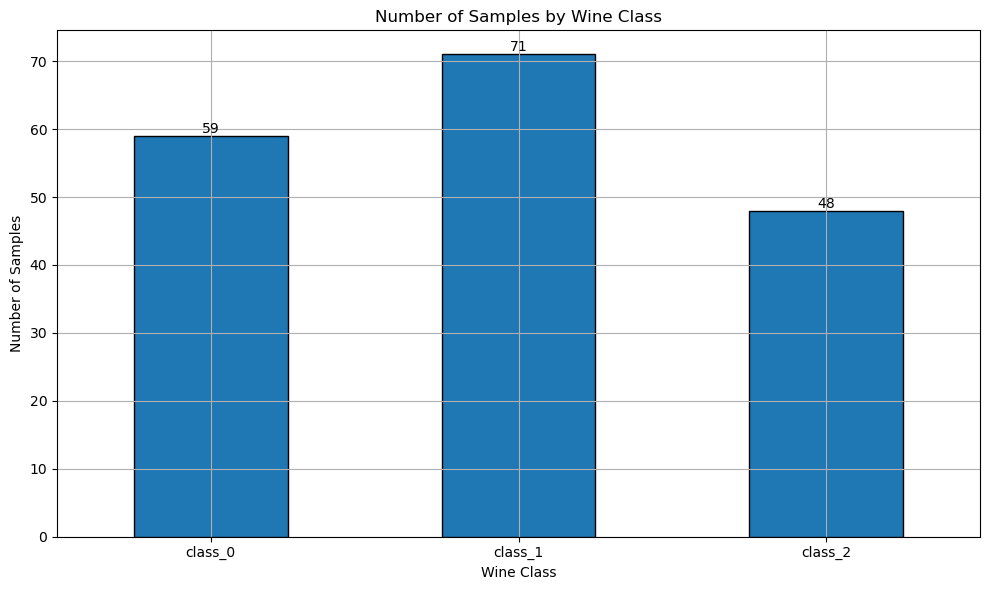

wine_class
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64

In [15]:
# Count the number of observations in each wine class
class_counts = df["wine_class"].value_counts().sort_index()

ax = class_counts.plot(kind="bar", edgecolor="black")
ax.set_title("Number of Samples by Wine Class")
ax.set_xlabel("Wine Class")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

class_counts

### Interpretation

The dataset is reasonably balanced across the three classes. Class 1 contains the largest number of observations, while Class 0 contains the fewest. Because no class overwhelmingly dominates the dataset, comparisons across classes remain meaningful.

## 4. Distribution of Alcohol Content

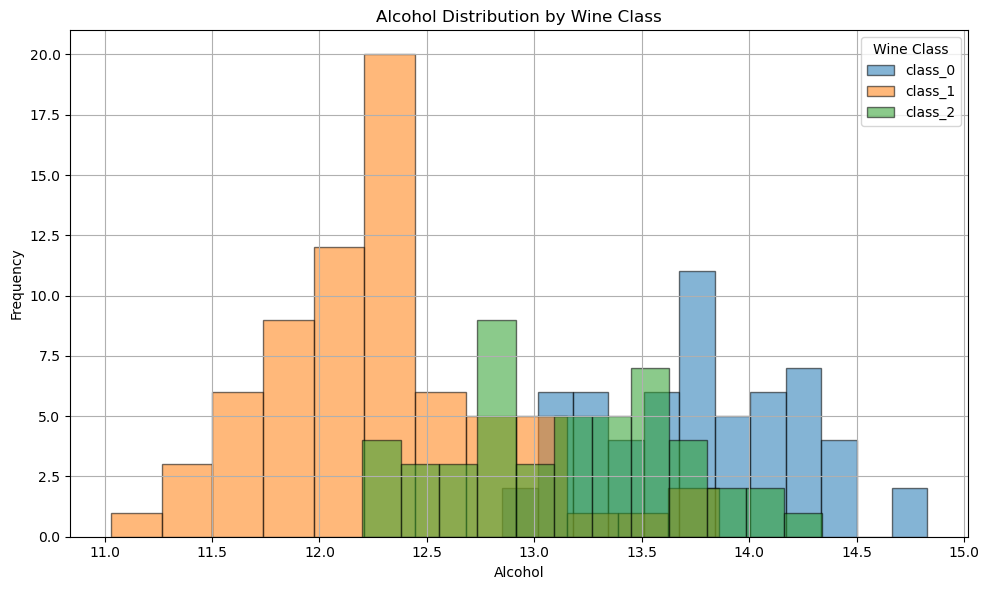

In [19]:
# Compare alcohol distributions for all three wine classes
for wine_class in sorted(df["wine_class"].unique()):
    values = df.loc[df["wine_class"] == wine_class, "alcohol"]
    plt.hist(values, bins=12, alpha=0.55, label=wine_class, edgecolor="black")

plt.title("Alcohol Distribution by Wine Class")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.legend(title="Wine Class")
plt.tight_layout()
plt.show()

### Interpretation

Class 0 generally has higher alcohol measurements than Classes 1 and 2. Alcohol content provides useful separation, although some overlap remains between classes.

## 5. Proline Comparison by Wine Class

C:\Users\lala_\AppData\Local\Temp\ipykernel_23356\1612253586.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(proline_groups, labels=classes, patch_artist=False)


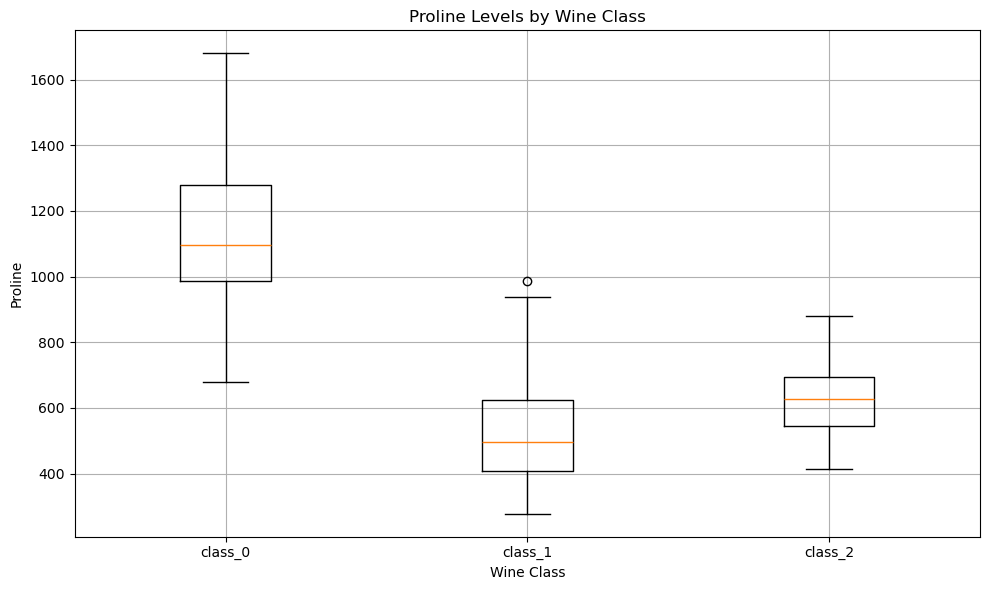

,count,mean,median,min,max
wine_class,,,,,
class_0,59,1115.71,1095.0,680.0,1680.0
class_1,71,519.51,495.0,278.0,985.0
class_2,48,629.90,627.5,415.0,880.0


In [23]:
# Create a box plot to compare proline values by class
classes = sorted(df["wine_class"].unique())
proline_groups = [df.loc[df["wine_class"] == wine_class, "proline"] for wine_class in classes]

plt.boxplot(proline_groups, labels=classes, patch_artist=False)
plt.title("Proline Levels by Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Proline")
plt.tight_layout()
plt.show()

# Display class-level summary values
df.groupby("wine_class")["proline"].agg(["count", "mean", "median", "min", "max"]).round(2)

### Interpretation

Proline differs substantially across the wine classes. Class 0 has the highest typical proline values, while Class 1 has the lowest. This makes proline one of the strongest visual indicators for distinguishing the classes.

## 6. Alcohol and Color Intensity Relationship

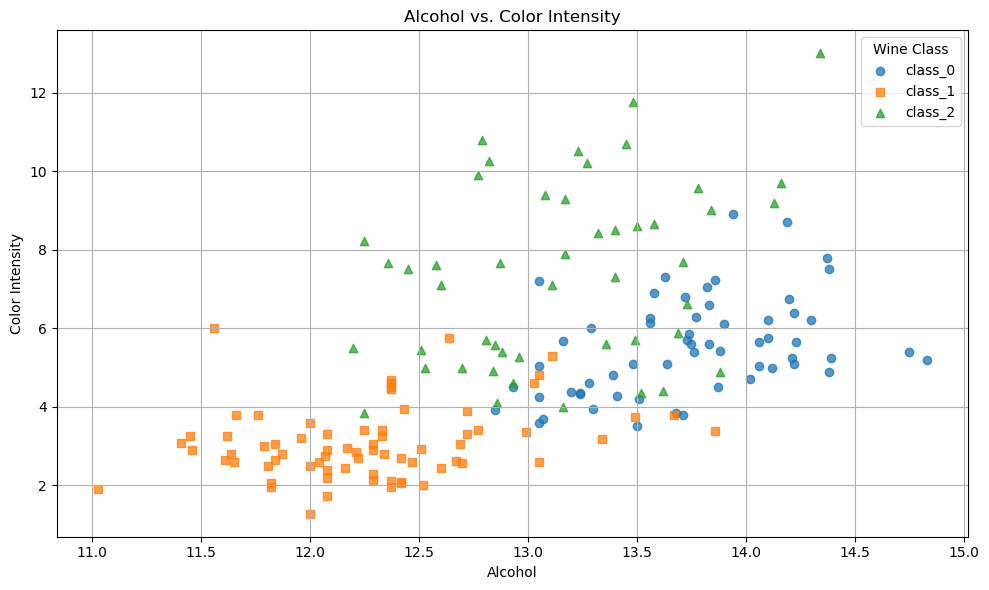

In [27]:
# Create a scatter plot for alcohol and color intensity
markers = ["o", "s", "^"]

for marker, wine_class in zip(markers, sorted(df["wine_class"].unique())):
    subset = df[df["wine_class"] == wine_class]
    plt.scatter(
        subset["alcohol"],
        subset["color_intensity"],
        marker=marker,
        alpha=0.75,
        label=wine_class
    )

plt.title("Alcohol vs. Color Intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")
plt.legend(title="Wine Class")
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows visible class groupings. Class 1 tends to have lower color intensity, while Class 2 frequently has higher color intensity combined with moderate alcohol values. Class 0 is concentrated toward higher alcohol values.

## 7. Average Feature Values by Class

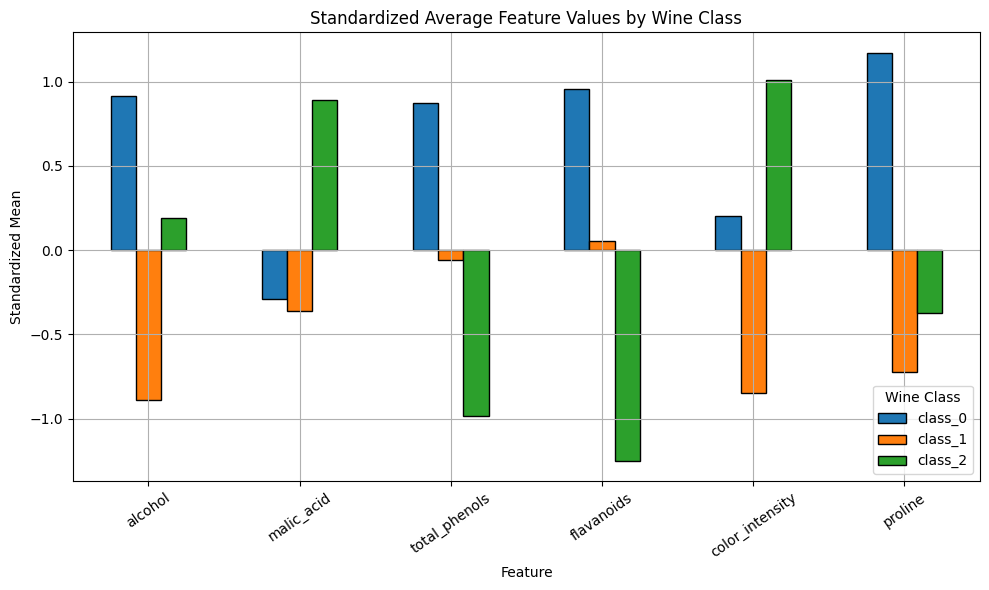

wine_class,class_0,class_1,class_2
alcohol,0.92,-0.89,0.19
malic_acid,-0.29,-0.36,0.89
total_phenols,0.87,-0.06,-0.98
flavanoids,0.95,0.05,-1.25
color_intensity,0.20,-0.85,1.01
proline,1.17,-0.72,-0.37


In [9]:
# Compare standardized class averages for selected features
selected_features = [
    "alcohol", "malic_acid", "total_phenols",
    "flavanoids", "color_intensity", "proline"
]

standardized = df[selected_features].apply(
    lambda column: (column - column.mean()) / column.std()
)
standardized["wine_class"] = df["wine_class"]
class_means = standardized.groupby("wine_class").mean().T

ax = class_means.plot(kind="bar", edgecolor="black")
ax.set_title("Standardized Average Feature Values by Wine Class")
ax.set_xlabel("Feature")
ax.set_ylabel("Standardized Mean")
ax.tick_params(axis="x", rotation=35)
plt.legend(title="Wine Class")
plt.tight_layout()
plt.show()

class_means.round(2)

### Interpretation

Standardization allows features with different measurement scales to be compared on one chart. The visualization highlights several class differences:

- Class 0 is above average in alcohol, flavanoids, total phenols, and proline.
- Class 1 is generally lower in alcohol and color intensity.
- Class 2 has higher color intensity but lower flavanoids and total phenols.

## 8. Correlation Heatmap

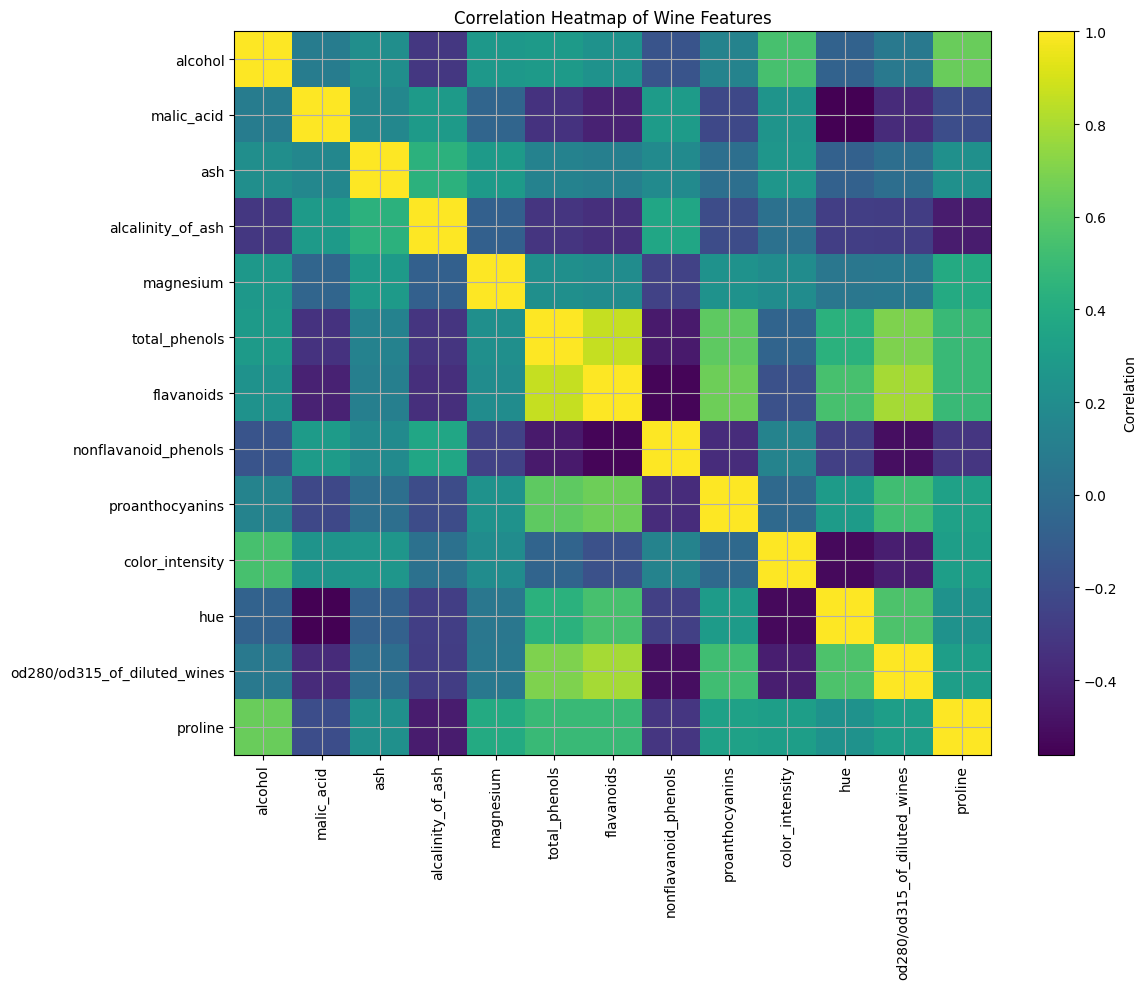

In [10]:
# Calculate correlations among numeric features
correlation = df.drop(columns="wine_class").corr()

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(correlation, aspect="auto")
fig.colorbar(image, ax=ax, label="Correlation")

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=90)
ax.set_yticklabels(correlation.columns)
ax.set_title("Correlation Heatmap of Wine Features")

plt.tight_layout()
plt.show()

In [11]:
# List the strongest absolute correlations, excluding self-correlations
corr_pairs = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
).stack()

strongest_correlations = (
    corr_pairs.abs()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("absolute_correlation")
)
strongest_correlations

,,absolute_correlation
total_phenols,flavanoids,0.864564
flavanoids,od280/od315_of_diluted_wines,0.787194
total_phenols,od280/od315_of_diluted_wines,0.699949
flavanoids,proanthocyanins,0.652692
alcohol,proline,0.643720
total_phenols,proanthocyanins,0.612413
hue,od280/od315_of_diluted_wines,0.565468
malic_acid,hue,0.561296
alcohol,color_intensity,0.546364
flavanoids,hue,0.543479


### Interpretation

Several chemical measurements move together. Flavanoids, total phenols, and related phenolic measurements have strong positive relationships. Some features may therefore provide overlapping information in future statistical or machine-learning models.

## 9. Key Findings

1. **Proline is highly useful for class comparison.** Class 0 has noticeably higher proline values than the other classes.
2. **Alcohol content differs across classes.** Class 0 tends to have the highest alcohol measurements.
3. **Color intensity helps distinguish Class 2.** Class 2 frequently shows higher color intensity than Class 1.
4. **Phenolic features are related.** Total phenols and flavanoids show similar patterns and strong correlation.
5. **Multiple features are needed for complete separation.** No single chart perfectly separates every observation, but combinations such as alcohol and color intensity reveal clear group structure.